# Hierarchical delta/theta/gamma binding and multi-object tracking

This notebook shows how PRIN turns oscillator dynamics into a trainable object
tracker. You will learn how the hierarchical band layers are constructed and
where their parameters actually live (Rust, not PyTorch), how to run a real
training loop on synthetic temporal CLEVR-N with `TemporalTrainer`, how the
per-band order parameters and PAC indices behave, why three frequency-separated
oscillator clusters bind *within* an object while staying separable *between*
objects, and how to score a tracker with `evaluate_tracking`.

**Runtime budget: ~40 s on CPU** (measured on the maintainer host: Windows,
Python 3.14, torch 2.11.0 CPU). No GPU, no network access, every seed
explicit.

**Scale note — read this before quoting any number below.** The archived
PRINet 3.0 notebook this one is ported from trained two CLEVR-N models for
**50 epochs** each and then repeated that across five object counts, using
`train_clevr_n_single_seed`. In PRIN that helper is a declared stub
(`prin.train_clevr_n_single_seed` raises on call), so this notebook instead
drives the real, supported path — `prin.temporal_training.TemporalTrainer` over
synthetic temporal CLEVR-N — for **8 epochs on 8 training sequences**, and the
object-count sweep for **3 epochs on 4 sequences**. Those are *smoke runs*:
they demonstrate that the API works end-to-end and that gradients flow through
the Rust dynamics. They are **not** accuracy, capacity, or scaling results, and
per PRIN's Experimentation Standards no conclusion may be drawn from them. The
governed campaigns behind `prin.simulation_experiments` and the paper's tables
use 50–100 epochs, 5 seeds, and held-out evaluation.

**Prerequisites:** `pip install -e ".[all]"`. Section 6 additionally needs the
`mot` extra (`motmetrics`), which `all` includes.

In [1]:
import numpy as np
import torch

import prin
from prin.dynamics import (
    CouplingMode,
    KuramotoOscillator,
    OscillatorState,
    RK4Integrator,
)
from prin.nn import (
    DiscreteDeltaThetaGamma,
    HierarchicalResonanceLayer,
    evaluate_tracking,
    generate_linear_mot_sequence,
)
from prin.nn.temporal_compat import PhaseTracker, TemporalSlotAttentionMOT
from prin.temporal_training import (
    TemporalTrainer,
    count_parameters,
    generate_dataset,
    generate_temporal_clevr_n,
)

# `import prin` forces matplotlib's non-interactive Agg backend, so the inline
# magic must follow it (see notebook 01 for the details).
%matplotlib inline

import matplotlib.pyplot as plt

DEVICE = "cpu"
SEED = 42
torch.manual_seed(SEED)

print(f"prin {prin.__version__} | torch {torch.__version__} | device {DEVICE}")

prin 0.3.0 | torch 2.11.0+cu128 | device cpu


## 1. Architecture and where the parameters live

PRIN exposes two hierarchical band networks and two trackers:

| Symbol | Role |
|---|---|
| `HierarchicalResonanceLayer` | continuous δ/θ/γ resonance: sparse phase-kNN Kuramoto RK4 stepping, amplitude dynamics, δ→θ and θ→γ PAC |
| `DiscreteDeltaThetaGamma` | discrete-time multi-rate variant with learned per-band coupling and soft-clamped Stuart–Landau amplitudes |
| `prin.nn.temporal_compat.PhaseTracker` | PRINet-3.0-compatible tracker: detection→phase/amplitude encoders + `DiscreteDeltaThetaGamma` dynamics |
| `prin.nn.temporal_compat.TemporalSlotAttentionMOT` | the slot-attention baseline the tracker is compared against |

The important structural fact is the **split of parameter ownership**. Almost
all of `HierarchicalResonanceLayer`'s numerics — the three band projections and
both PAC depths — are owned by the Rust bridge, so they are *not*
`torch.nn.Parameter`s and do not appear in `named_parameters()`. Only two
value-preserving mirrors stay on the PyTorch side. `rust_state_dict()` is the
handle on the Rust-owned half.

In [2]:
hrl = HierarchicalResonanceLayer(
    n_delta=8, n_theta=16, n_gamma=64, n_dims=256, n_steps=10,
    coupling_strength=2.0, pac_depth=0.3, seed_counter=0, seed_key=SEED,
)
dtg = DiscreteDeltaThetaGamma(n_delta=8, n_theta=16, n_gamma=64)

# The temporal_compat models take no Seed argument: their encoders are plain
# torch.nn.Linear stacks, so determinism comes from seeding torch before
# construction rather than from a PRIN Seed.
torch.manual_seed(SEED)
tracker = PhaseTracker(detection_dim=4, n_delta=4, n_theta=8, n_gamma=16,
                       n_discrete_steps=5, match_threshold=0.3)
torch.manual_seed(SEED)
slot_model = TemporalSlotAttentionMOT(detection_dim=4, num_slots=8, slot_dim=64,
                                      num_iterations=3, match_threshold=0.3)

rust_owned = hrl.n_total * hrl.n_dims + 2
state_bytes = len(hrl.rust_state_dict())

print(f"{'model':<28} {'torch params':>13} {'Rust-owned':>11} {'output width':>13}")
print(f"{'HierarchicalResonanceLayer':<28} "
      f"{sum(p.numel() for p in hrl.parameters()):>13,} {rust_owned:>11,} "
      f"{hrl.n_total:>13}")
print(f"{'DiscreteDeltaThetaGamma':<28} "
      f"{sum(p.numel() for p in dtg.parameters()):>13,} {'-':>11} {dtg.n_total:>13}")
print(f"{'PhaseTracker':<28} "
      f"{sum(p.numel() for p in tracker.parameters()):>13,} {'(Rust dyn.)':>11} {'-':>13}")
print(f"{'TemporalSlotAttentionMOT':<28} "
      f"{sum(p.numel() for p in slot_model.parameters()):>13,} {'(Rust dyn.)':>11} {'-':>13}")

print()
print("HierarchicalResonanceLayer torch-side parameters:",
      [(n, tuple(p.shape)) for n, p in hrl.named_parameters()])
print("bands                       : delta/theta/gamma =",
      hrl.n_delta, hrl.n_theta, hrl.n_gamma, "| n_total =", hrl.n_total)
print("Rust-owned count            : n_total * n_dims + 2 =",
      hrl.n_total, "*", hrl.n_dims, "+ 2 =", rust_owned)
print("len(rust_state_dict())      :", f"{state_bytes:,}", "bytes ->",
      f"{state_bytes / rust_owned:.3f} bytes per f64 value (payload + record header)")
print("count_parameters(PhaseTracker):", count_parameters(tracker))

x = torch.randn(16, 256, generator=torch.Generator().manual_seed(SEED))
amps, phases = hrl(x, return_phase=True)
print()
print(f"hrl.forward((16, 256)) -> amplitudes {tuple(amps.shape)}, "
      f"phases {tuple(phases.shape)}")
print(f"phase range [{float(phases.min()):.4f}, {float(phases.max()):.4f}] rad "
      "(wrapped to [0, 2pi))")
print(f"DiscreteDeltaThetaGamma named_parameters: "
      f"{[n for n, _ in dtg.named_parameters()]}")

model                         torch params  Rust-owned  output width
HierarchicalResonanceLayer               2      22,530            88
DiscreteDeltaThetaGamma              6,891           -            88
PhaseTracker                         4,991 (Rust dyn.)             -
TemporalSlotAttentionMOT            83,904 (Rust dyn.)             -

HierarchicalResonanceLayer torch-side parameters: [('pac_depth_dt', ()), ('pac_depth_tg', ())]
bands                       : delta/theta/gamma = 8 16 64 | n_total = 88
Rust-owned count            : n_total * n_dims + 2 = 88 * 256 + 2 = 22530
len(rust_state_dict())      : 180,495 bytes -> 8.011 bytes per f64 value (payload + record header)
count_parameters(PhaseTracker): {'total': 4991, 'trainable': 4991, 'frozen': 0, 'complex_adjusted': 4991}



hrl.forward((16, 256)) -> amplitudes (16, 88), phases (16, 88)
phase range [0.0066, 6.2821] rad (wrapped to [0, 2pi))
DiscreteDeltaThetaGamma named_parameters: ['delta_freq', 'theta_freq', 'gamma_freq', 'W_delta', 'W_theta', 'W_gamma', 'mu_delta', 'mu_theta', 'mu_gamma', 'W_pac_dt.weight', 'W_pac_dt.bias', 'W_pac_tg.weight', 'W_pac_tg.bias']


## 2. A real training run on synthetic temporal CLEVR-N

`generate_temporal_clevr_n` builds one sequence of moving objects with
ground-truth identities; `generate_dataset` builds a list of them from a base
seed. `TemporalTrainer` then drives the identical loss, optimizer, warmup,
cosine schedule, gradient clipping, and early stopping that the governed
comparison uses for both the tracker and the slot-attention baseline.

The loss is `hungarian_similarity_loss` over the frame-to-frame phase
similarity matrix, plus 0.1 × `temporal_smoothness_loss`. Because the
similarity matrix comes out of the Rust band dynamics through the DLPack
bridge, a falling training loss is direct evidence that the gradient path into
Rust is live.

sequence: 20 frames x 4 objects, detection tensor (4, 4)
          positions (20, 4, 2), identities (20, 4)
dataset : 8 train / 3 val sequences


epochs run       : 8
train loss       : 0.8875 -> 0.4838
val loss         : 0.9784 -> 0.7593
val identity pres: 0.7149 -> 0.9605
best epoch / loss: 7 / 0.7727
wall time        : 5.38 s


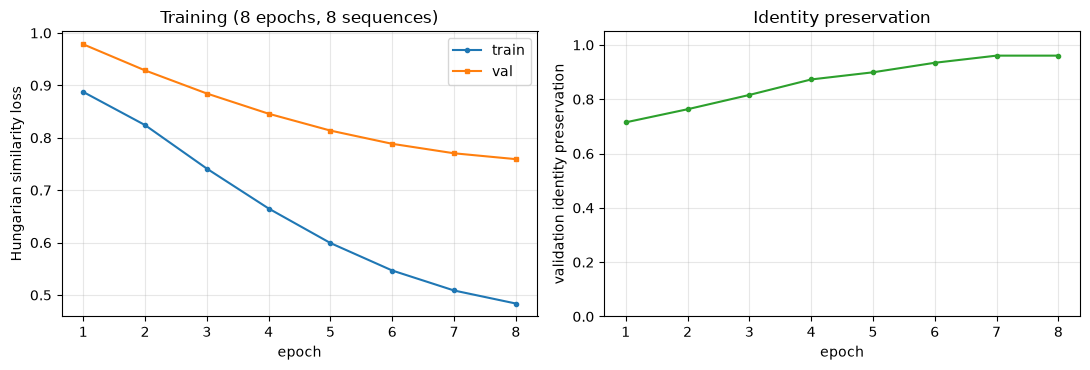

snapshot epoch  0: grad_norm=1.0000 param_norm=161.239 phase_coherence=0.1130
snapshot epoch  7: grad_norm=1.0000 param_norm=161.185 phase_coherence=0.2019


In [3]:
N_TRAIN, N_VAL, N_FRAMES, EPOCHS = 8, 3, 20, 8

train_data = generate_dataset(N_TRAIN, n_objects=4, n_frames=N_FRAMES,
                              det_dim=4, base_seed=SEED)
val_data = generate_dataset(N_VAL, n_objects=4, n_frames=N_FRAMES,
                            det_dim=4, base_seed=SEED + 1000)

one = generate_temporal_clevr_n(n_objects=4, n_frames=N_FRAMES, det_dim=4, seed=SEED)
print(f"sequence: {one.n_frames} frames x {one.n_objects} objects, "
      f"detection tensor {tuple(one.frames[0].shape)}")
print(f"          positions {tuple(one.positions.shape)}, "
      f"identities {tuple(one.identities.shape)}")
print(f"dataset : {len(train_data)} train / {len(val_data)} val sequences")

torch.manual_seed(SEED)
train_model = PhaseTracker(detection_dim=4, n_delta=4, n_theta=8, n_gamma=16,
                           n_discrete_steps=5)
trainer = TemporalTrainer(
    train_model, lr=3e-4, weight_decay=0.0, max_epochs=EPOCHS, patience=EPOCHS,
    smoothing_window=3, warmup_epochs=2, grad_clip=1.0,
    snapshot_epochs=(0, EPOCHS - 1), device=DEVICE, seed=SEED,
)
result = trainer.train(train_data, val_data)

print(f"epochs run       : {result.total_epochs}")
print(f"train loss       : {result.train_losses[0]:.4f} -> "
      f"{result.train_losses[-1]:.4f}")
print(f"val loss         : {result.val_losses[0]:.4f} -> {result.final_val_loss:.4f}")
print(f"val identity pres: {result.val_ips[0]:.4f} -> {result.final_val_ip:.4f}")
print(f"best epoch / loss: {result.best_epoch} / {result.best_val_loss:.4f}")
print(f"wall time        : {result.wall_time_s:.2f} s")

epochs_axis = np.arange(1, result.total_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(epochs_axis, result.train_losses, "o-", label="train", markersize=3)
axes[0].plot(epochs_axis, result.val_losses, "s-", label="val", markersize=3)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Hungarian similarity loss")
axes[0].set_title(f"Training ({EPOCHS} epochs, {N_TRAIN} sequences)")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(epochs_axis, result.val_ips, "o-", color="#2ca02c", markersize=3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation identity preservation")
axes[1].set_title("Identity preservation")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

for snap in result.snapshots:
    print(f"snapshot epoch {snap.epoch:>2}: grad_norm={snap.gradient_norm:.4f} "
          f"param_norm={snap.param_norm:.3f} phase_coherence={snap.phase_coherence:.4f}")

## 3. Object-count sweep (API smoke test, not a scaling result)

The reference notebook used this sweep to argue that binding cost grows
linearly in the object count. Reproducing that claim needs 50 epochs, 5 seeds,
and a held-out test split. What follows runs **3 epochs on 4 sequences** per
object count, purely to show that every entry point accepts a different N and
to make the wall-clock structure visible.

Note what the timing does and does not measure: the oscillator network is a
fixed size (`n_delta=4, n_theta=8, n_gamma=16`) regardless of how many objects
are in the scene, so per-epoch wall time is dominated by the dynamics, not by
N. That is a property of this architecture, and it is exactly why a tutorial
sweep like this one cannot substitute for the governed capacity campaign.

  N  epochs   loss_0   loss_T   val IP   wall s  s/epoch
  2       3   0.3603   0.3025   0.9474     1.02     0.34
  4       3   0.9132   0.8117   0.6908     1.10     0.37
  6       3   1.2233   1.1153   0.6316     1.17     0.39
  8       3   1.5385   1.4189   0.7336     1.60     0.53
 10       3   1.7614   1.6432   0.7553     1.30     0.43


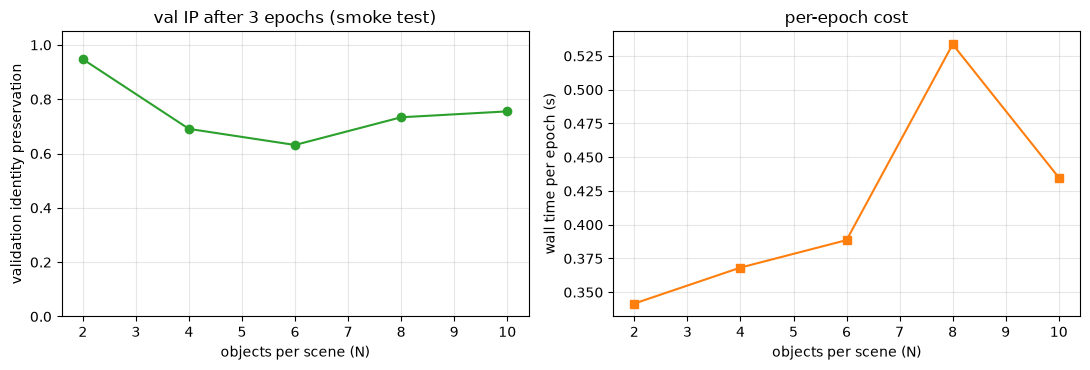

In [4]:
SWEEP_EPOCHS, SWEEP_TRAIN, SWEEP_VAL = 3, 4, 2
sweep_rows = []

for n_objects in (2, 4, 6, 8, 10):
    s_train = generate_dataset(SWEEP_TRAIN, n_objects=n_objects, n_frames=N_FRAMES,
                               det_dim=4, base_seed=SEED)
    s_val = generate_dataset(SWEEP_VAL, n_objects=n_objects, n_frames=N_FRAMES,
                             det_dim=4, base_seed=SEED + 1000)
    torch.manual_seed(SEED)
    s_model = PhaseTracker(detection_dim=4, n_delta=4, n_theta=8, n_gamma=16,
                           n_discrete_steps=5)
    s_trainer = TemporalTrainer(
        s_model, lr=3e-4, max_epochs=SWEEP_EPOCHS, patience=SWEEP_EPOCHS,
        smoothing_window=2, warmup_epochs=1, snapshot_epochs=(0,),
        device=DEVICE, seed=SEED,
    )
    s_result = s_trainer.train(s_train, s_val)
    sweep_rows.append(
        (n_objects, s_result.total_epochs, s_result.train_losses[0],
         s_result.train_losses[-1], s_result.final_val_ip, s_result.wall_time_s)
    )

print(f"{'N':>3} {'epochs':>7} {'loss_0':>8} {'loss_T':>8} {'val IP':>8} "
      f"{'wall s':>8} {'s/epoch':>8}")
for n_obj, ep, l0, lT, ip, wall in sweep_rows:
    print(f"{n_obj:>3} {ep:>7} {l0:>8.4f} {lT:>8.4f} {ip:>8.4f} {wall:>8.2f} "
          f"{wall / max(ep, 1):>8.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
counts = [r[0] for r in sweep_rows]
axes[0].plot(counts, [r[4] for r in sweep_rows], "o-", color="#2ca02c")
axes[0].set_xlabel("objects per scene (N)")
axes[0].set_ylabel("validation identity preservation")
axes[0].set_title(f"val IP after {SWEEP_EPOCHS} epochs (smoke test)")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[1].plot(counts, [r[5] / max(r[1], 1) for r in sweep_rows], "s-", color="#ff7f0e")
axes[1].set_xlabel("objects per scene (N)")
axes[1].set_ylabel("wall time per epoch (s)")
axes[1].set_title("per-epoch cost")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Band dynamics: per-band order parameters and PAC

`DiscreteDeltaThetaGamma` owns the three bands as one flat oscillator vector of
width `n_total = n_delta + n_theta + n_gamma`. `order_parameters` slices that
vector per band and returns the Kuramoto *R* of each; `pac_index` returns the
δ→θ and θ→γ phase–amplitude coupling indices.

One behaviour is worth seeing explicitly rather than discovering later. At the
**untrained default initialization** (`mu_delta = mu_theta = mu_gamma = 1.0`,
`pac_depth = 0.3`), the θ- and γ-band amplitudes are driven down to the
Stuart–Landau clamp floor of 1e-6 within about 20 macro steps while the δ band
stays at 1.0 — the printed mean amplitude settles at 8/88, i.e. exactly the δ
oscillators. The phases keep evolving and the band order parameters stay in a
normal range, so this notebook reports *R* and PAC rather than amplitude
magnitudes. Whether that envelope collapse is the intended pre-training state
or a defect is a question for the numerical owner; it is reproduced here, not
interpreted.

initial  R_delta=0.8574  R_theta=0.8037  R_gamma=0.8275
 step  R_delta  R_theta  R_gamma  PAC_dt  PAC_tg   mean|A|    min|A|
    4   0.8739   0.7708   0.8277  0.8630  0.9382    0.2041  1.27e-02
    8   0.8532   0.7631   0.8397  0.8127  0.9196    0.1059  2.85e-04
   12   0.9062   0.8334   0.8067  0.7723  0.8724    0.0928  6.93e-06
   16   0.9196   0.7716   0.8306  0.8441  0.9034    0.0912  1.00e-06
   20   0.8554   0.7824   0.8224  0.8181  0.9180    0.0910  1.00e-06
   24   0.8305   0.8390   0.8313  0.8660  0.9112    0.0909  1.00e-06
   28   0.8353   0.7393   0.8323  0.8897  0.8165    0.0909  1.00e-06
   32   0.8026   0.7796   0.7861  0.8386  0.9447    0.0909  1.00e-06
   36   0.6931   0.8232   0.8374  0.8813  0.8791    0.0909  1.00e-06
   40   0.8884   0.8566   0.8160  0.9192  0.9694    0.0909  1.00e-06


integrate(40 steps) -> phase (8, 88), amplitude (8, 88)
phase wrapped to [0.0036, 6.2662] rad


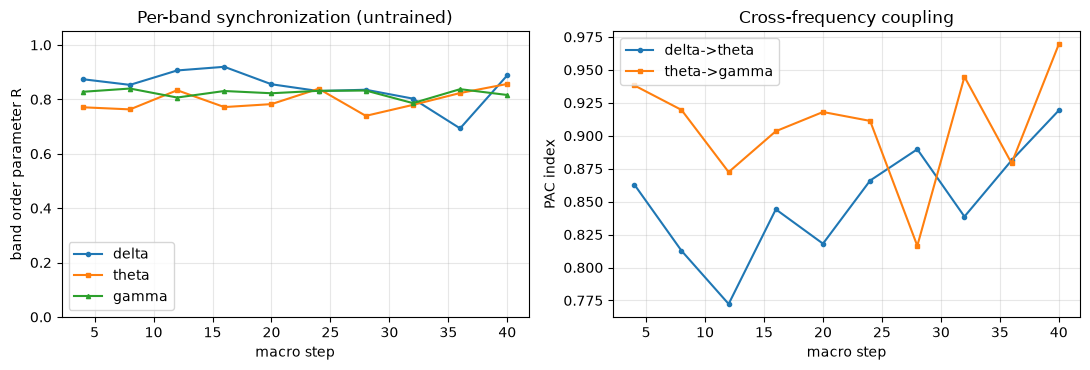

In [5]:
band_gen = torch.Generator().manual_seed(SEED)
band_phase = torch.rand(8, dtg.n_total, generator=band_gen) * 2 * torch.pi
band_amp = torch.ones(8, dtg.n_total)

r_d, r_t, r_g = dtg.order_parameters(band_phase)
print(f"initial  R_delta={float(r_d):.4f}  R_theta={float(r_t):.4f}  "
      f"R_gamma={float(r_g):.4f}")

history = []
amp_rows = []
step_phase, step_amp = band_phase.clone(), band_amp.clone()
for step in range(40):
    step_phase, step_amp = dtg.step(step_phase, step_amp, dt=0.01)
    if step % 4 == 3:
        with torch.no_grad():
            r_d, r_t, r_g = dtg.order_parameters(step_phase)
            pac_dt, pac_tg = dtg.pac_index(step_phase, step_amp)
        history.append((step + 1, float(r_d), float(r_t), float(r_g),
                        float(pac_dt), float(pac_tg)))
        amp_rows.append((step + 1, float(step_amp.detach().mean()),
                         float(step_amp.detach().min())))

print(f"{'step':>5} {'R_delta':>8} {'R_theta':>8} {'R_gamma':>8} "
      f"{'PAC_dt':>7} {'PAC_tg':>7} {'mean|A|':>9} {'min|A|':>9}")
for row, amp_row in zip(history, amp_rows, strict=True):
    print(f"{row[0]:>5} {row[1]:>8.4f} {row[2]:>8.4f} {row[3]:>8.4f} "
          f"{row[4]:>7.4f} {row[5]:>7.4f} {amp_row[1]:>9.4f} {amp_row[2]:>9.2e}")

with torch.no_grad():
    final_phase, final_amp = dtg.integrate(band_phase, band_amp, n_steps=40, dt=0.01)
print(f"integrate(40 steps) -> phase {tuple(final_phase.shape)}, "
      f"amplitude {tuple(final_amp.shape)}")
print(f"phase wrapped to [{float(final_phase.min()):.4f}, "
      f"{float(final_phase.max()):.4f}] rad")

steps_axis = [row[0] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(steps_axis, [r[1] for r in history], "o-", markersize=3, label="delta")
axes[0].plot(steps_axis, [r[2] for r in history], "s-", markersize=3, label="theta")
axes[0].plot(steps_axis, [r[3] for r in history], "^-", markersize=3, label="gamma")
axes[0].set_xlabel("macro step")
axes[0].set_ylabel("band order parameter R")
axes[0].set_title("Per-band synchronization (untrained)")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(steps_axis, [r[4] for r in history], "o-", markersize=3, label="delta->theta")
axes[1].plot(steps_axis, [r[5] for r in history], "s-", markersize=3, label="theta->gamma")
axes[1].set_xlabel("macro step")
axes[1].set_ylabel("PAC index")
axes[1].set_title("Cross-frequency coupling")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)

## 5. Phase dynamics during binding

This is the mechanism the whole architecture rests on, shown on its own with
the low-level Rust core (`prin.dynamics`) rather than through a network.

Twenty-four oscillators are split into three groups of eight. Each group gets a
narrow natural-frequency band around 2, 5, and 8 **rad/s** respectively (a
0.05 rad/s spread within each group, drawn from an explicitly seeded
`numpy.random.default_rng`), so intra-group locking is a genuine dynamical
achievement rather than a tautology. Mean-field Kuramoto coupling at K = 2 then
does two things at once:

- **within** a group, oscillators phase-lock, so that group's *R* rises to 1.000
  and stays there — that is *binding*;
- **between** groups, the 3 rad/s frequency separation is far larger than the
  coupling can absorb, so the three group phases keep precessing past one
  another and the global *R* beats between ≈ 0.12 and ≈ 0.99 — that is
  *separability*.

Binding is therefore not a weighted sum of features as in attention; an object
is a phase-coherent cluster, and two objects are distinguishable because their
cluster phases precess apart.

> **Unit warning.** `prin.dynamics` frequencies are in **rad/s** —
> `KuramotoOscillator` computes `dphase = frequency + coupling` with no 2π
> factor (`crates/prin-dynamics/src/models.rs`). `OscilloSim`'s
> `freq_mean`/`freq_std` are in **hertz**; there the Rust core multiplies by 2π
> (`crates/prin-sim/src/oscillo_compat.rs`). The same number means different
> things on the two surfaces.

> **Mutation warning.** `OscillatorState.phase`, `.amplitude`, and `.frequency`
> each return a **fresh copy**, and the attributes are read-only. Writing
> `state.frequency[0:8] = 2.0` therefore succeeds silently and changes nothing.
> Build the arrays first and pass them to the public
> `OscillatorState(phase, amplitude, frequency, freq_band=None)` constructor —
> which is what the cell below does. `freq_band` optionally labels each
> oscillator with a band id, exposed as `state.n_bands`.

state      : 24 oscillators, 3 bands, len()=24
frequencies: [2.015 4.999 8.018] rad/s (cluster centres), spread 0.05
freq_band  : [0, 0, 0, 0, 0, 0, 0, 0, 1, 1] ... (first 10 of 24)
simulated time         : 11.9 s (1200 RK4 steps at dt=0.01)
cluster R, final third : mean [1. 1. 1.] | min [1. 1. 1.]
global  R, whole run   : mean 0.8653, min 0.1168, max 0.9923
frequency drift        : max |omega_T - omega_0| = 0.00e+00 (freq_adaptation_rate=0)


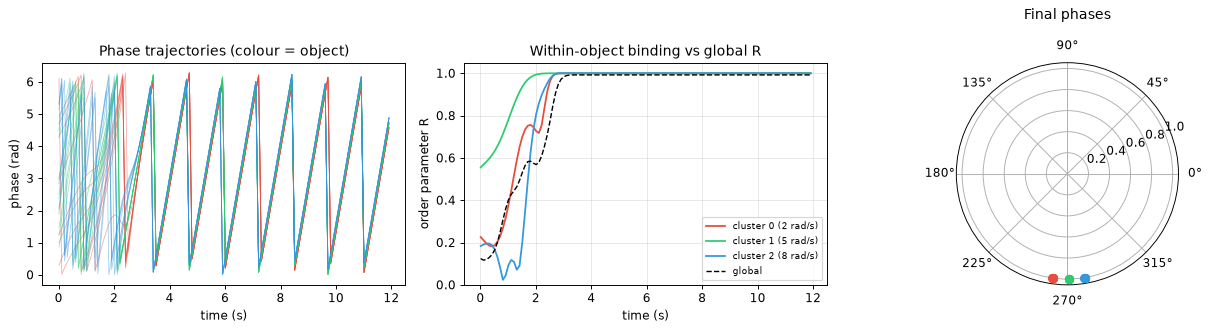

In [6]:
N_BIND, K_BIND, N_STEPS, DT = 24, 2.0, 1_200, 0.01
CLUSTERS = ((0, 8, 2.0), (8, 16, 5.0), (16, 24, 8.0))
FREQ_SPREAD = 0.05
CLUSTER_COLOURS = ["#e74c3c", "#2ecc71", "#3498db"]

bind_rng = np.random.default_rng(SEED)
bind_frequency = np.empty(N_BIND)
for low, high, centre in CLUSTERS:
    bind_frequency[low:high] = centre + bind_rng.normal(0.0, FREQ_SPREAD, high - low)
bind_phase = bind_rng.uniform(0.0, 2 * np.pi, N_BIND)
bind_amplitude = np.ones(N_BIND)
bind_bands = np.repeat(np.arange(len(CLUSTERS), dtype=np.uint32),
                       N_BIND // len(CLUSTERS))

bind_state = OscillatorState(bind_phase, bind_amplitude, bind_frequency, bind_bands)
print(f"state      : {bind_state.n_oscillators} oscillators, "
      f"{bind_state.n_bands} bands, len()={len(bind_state)}")
print(f"frequencies: {np.round([bind_frequency[low] for low, _, _ in CLUSTERS], 3)} "
      f"rad/s (cluster centres), spread {FREQ_SPREAD}")
print(f"freq_band  : {bind_state.freq_band[:10].tolist()} ... "
      f"(first 10 of {N_BIND})")

bind_model = KuramotoOscillator(N_BIND, K_BIND, 0.0, 0.0, CouplingMode.mean_field())
integrator = RK4Integrator()

time_axis, phase_history, global_R, cluster_R = [], [], [], []
for step in range(N_STEPS):
    bind_state = integrator.step(bind_model, bind_state, DT)
    if step % 10 == 0:
        time_axis.append((step + 1) * DT)
        phase_history.append(bind_state.phase.copy())
        global_R.append(float(prin.kuramoto_order_parameter(bind_state.phase)))
        cluster_R.append([
            float(prin.kuramoto_order_parameter(bind_state.phase[low:high]))
            for low, high, _ in CLUSTERS
        ])

phase_history = np.array(phase_history)
cluster_R = np.array(cluster_R)
late = slice(len(time_axis) // 3, None)

print(f"simulated time         : {time_axis[-1]:.1f} s "
      f"({N_STEPS} RK4 steps at dt={DT})")
print(f"cluster R, final third : mean "
      f"{np.round(cluster_R[late].mean(axis=0), 4)} | min "
      f"{np.round(cluster_R[late].min(axis=0), 4)}")
print(f"global  R, whole run   : mean {np.mean(global_R):.4f}, "
      f"min {np.min(global_R):.4f}, max {np.max(global_R):.4f}")
print(f"frequency drift        : max |omega_T - omega_0| = "
      f"{float(np.abs(bind_state.frequency - bind_frequency).max()):.2e} "
      "(freq_adaptation_rate=0)")

fig = plt.figure(figsize=(15, 4))
ax_traj = fig.add_subplot(1, 3, 1)
for index in range(N_BIND):
    group = index // (N_BIND // len(CLUSTERS))
    ax_traj.plot(time_axis, phase_history[:, index], color=CLUSTER_COLOURS[group],
                 alpha=0.45, linewidth=0.7)
ax_traj.set_xlabel("time (s)")
ax_traj.set_ylabel("phase (rad)")
ax_traj.set_title("Phase trajectories (colour = object)")

ax_r = fig.add_subplot(1, 3, 2)
for index, (_, _, centre) in enumerate(CLUSTERS):
    ax_r.plot(time_axis, cluster_R[:, index], color=CLUSTER_COLOURS[index],
              label=f"cluster {index} ({centre:.0f} rad/s)")
ax_r.plot(time_axis, global_R, color="black", linestyle="--", linewidth=1.2,
          label="global")
ax_r.set_xlabel("time (s)")
ax_r.set_ylabel("order parameter R")
ax_r.set_title("Within-object binding vs global R")
ax_r.set_ylim(0, 1.05)
ax_r.grid(alpha=0.3)
ax_r.legend(fontsize=8)

ax_polar = fig.add_subplot(1, 3, 3, projection="polar")
for index in range(N_BIND):
    group = index // (N_BIND // len(CLUSTERS))
    ax_polar.scatter(phase_history[-1, index], 1.0, s=45,
                     color=CLUSTER_COLOURS[group], zorder=3)
ax_polar.set_title("Final phases", pad=18)
fig.set_dpi(85)
plt.tight_layout()
plt.show()
plt.close(fig)

## 6. Multi-object tracking evaluation

`generate_linear_mot_sequence` produces frames of `Detection` records with
ground-truth identities, and `evaluate_tracking` runs a tracker frame by frame
and scores it through the Rust MOT metrics core (`prin.eval.MotAccumulator`).
It requires the `mot` extra; without `motmetrics` installed it raises
`ImportError` rather than degrading.

Both rows below use the same held-out sequence: the tracker as constructed, and
the tracker after the 8-epoch run of section 2. Read them as *API output*, not
as evidence that training improved tracking — one sequence, one seed, and a
smoke-run number of epochs cannot support that claim.

In [7]:
mot_sequence = generate_linear_mot_sequence(
    n_objects=6, n_frames=20, detection_dim=4, noise_std=0.02, miss_rate=0.05,
    seed=SEED,
)
print(f"sequence: {len(mot_sequence)} frames, "
      f"{len(mot_sequence[0])} detections in frame 0")
print(f"frame 0 detection 0: obj_id={mot_sequence[0][0].obj_id} "
      f"bbox={[round(v, 4) for v in mot_sequence[0][0].bbox]}")

torch.manual_seed(SEED)
untrained = PhaseTracker(detection_dim=4, n_delta=4, n_theta=8, n_gamma=16,
                         n_discrete_steps=5)

rows = []
for label, model in (("untrained", untrained), ("after 8 epochs", train_model)):
    scored = evaluate_tracking(mot_sequence, model, detection_dim=4,
                               device=DEVICE, sequence_name="linear-mot")
    rows.append((label, scored))

print(f"{'tracker':<16} {'MOTA':>7} {'MOTP':>7} {'IDF1':>7} {'IP':>7} "
      f"{'IDSW':>6} {'FP':>4} {'FN':>4}")
for label, scored in rows:
    print(f"{label:<16} {scored.mota:>7.3f} {scored.motp:>7.3f} {scored.idf1:>7.3f} "
          f"{scored.identity_preservation:>7.3f} {scored.id_switches:>6} "
          f"{scored.false_positives:>4} {scored.false_negatives:>4}")

print()
print("raw_metrics:", rows[0][1].raw_metrics)
print("TrackingResult fields: sequence_name, n_frames, n_objects, mota, motp, "
      "idf1, id_switches, false_positives, false_negatives, "
      "identity_preservation, raw_metrics")

sequence: 20 frames, 6 detections in frame 0
frame 0 detection 0: obj_id=0 bbox=[0.8619, 0.9066, 0.05, 0.1]
tracker             MOTA    MOTP    IDF1      IP   IDSW   FP   FN
untrained          0.519   0.363   0.269   0.519     52    0    0
after 8 epochs     0.639   0.133   0.491   0.639     39    0    0

raw_metrics: {'mota': 0.5185185185185186, 'motp': 0.3629629629629629, 'idf1': 0.26851851851851855, 'num_switches': 52, 'num_false_positives': 0, 'num_misses': 0}
TrackingResult fields: sequence_name, n_frames, n_objects, mota, motp, idf1, id_switches, false_positives, false_negatives, identity_preservation, raw_metrics


## Summary

| API used | What it gave you |
|---|---|
| `prin.nn.HierarchicalResonanceLayer` | continuous δ/θ/γ resonance; `(B, n_dims) → (B, n_total)` amplitudes and phases |
| `.rust_state_dict()` / `.n_total` | the Rust-owned half of the parameter set and the output width |
| `prin.nn.DiscreteDeltaThetaGamma` | `.step`, `.integrate`, `.order_parameters`, `.pac_index` |
| `prin.nn.temporal_compat.PhaseTracker` | tracker whose similarity matrix comes from the Rust band dynamics |
| `prin.nn.temporal_compat.TemporalSlotAttentionMOT` | the slot-attention baseline |
| `prin.temporal_training.generate_dataset` / `generate_temporal_clevr_n` | synthetic temporal CLEVR-N sequences with identities |
| `prin.temporal_training.TemporalTrainer.train` | real epochs: losses, val identity preservation, snapshots, wall time |
| `prin.temporal_training.count_parameters` | complex-aware parameter accounting |
| `prin.dynamics.OscillatorState(...)` | direct construction from explicit phase / amplitude / frequency arrays (plus an optional `freq_band`) |
| `prin.dynamics.{KuramotoOscillator, RK4Integrator, CouplingMode}` | the low-level binding demonstration |
| `prin.kuramoto_order_parameter` | global and per-cluster *R* |
| `prin.nn.generate_linear_mot_sequence` / `evaluate_tracking` | MOTA, MOTP, IDF1, ID switches via the Rust MOT core |

Two naming traps that cost time if you hit them cold. `prin.nn.PhaseTracker`
and `prin.nn.temporal_compat.PhaseTracker` are **different classes**: only the
latter has the `det_to_phase`/`dynamics` attributes that
`TemporalTrainer._is_phase_tracker` looks for, so passing the former makes the
trainer fall through to the slot-attention path and fail with
`AttributeError: 'PhaseTracker' object has no attribute 'process_frame'`. And
`prin.train_clevr_n_single_seed`, which the archived reference notebook used,
is a stub that raises.

Next: [`03_custom_coupling.ipynb`](03_custom_coupling.ipynb) builds coupling
topologies by hand and drives them through the same Rust core.